# 02 - Predictive GNN: Training and Evaluation

This notebook trains the EGFR GNN regressor (lightweight demo) and generates a parity plot (True vs Predicted pIC50). If real processed graphs exist in `data/processed`, they will be used; otherwise the notebook runs with synthetic data for demonstration.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn torch-geometric tensorboard biopython 

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports and setup
# Keep warning noise out of the notebook so the training signal is easier to read.
import sys
import importlib
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='.*IProgress not found.*')

from pathlib import Path
import numpy as np, pandas as pd
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
import core.gnn_architecture as gnn_architecture
importlib.reload(gnn_architecture)
from core.gnn_architecture import EGFR_GNN_Regressor

OUT = ROOT / 'results' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)

# Reload the local model module and choose the best available accelerator for training.
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Environment ready; using device: {device}')

Environment ready; using device: cuda


In [3]:
# Load processed graphs AND aligned labels from the processed bundle / bioactivity CSV
DATA_PROC = ROOT / 'data' / 'processed'
DATA_RAW = ROOT / 'data' / 'raw' / 'bioactivity'

from collections import defaultdict


def normalize_edge_index(graph):
    """Ensure PyG edge_index uses shape [2, num_edges]."""
    if hasattr(graph, 'edge_index') and graph.edge_index is not None:
        edge_index = graph.edge_index
        if edge_index.ndim == 2 and edge_index.shape[0] != 2 and edge_index.shape[1] == 2:
            graph.edge_index = edge_index.t().contiguous()
    return graph


def compute_aligned_targets(csv_file):
    """Rebuild the same filtered pIC50 ordering used in Notebook 01."""
    df = pd.read_csv(csv_file)
    if 'Smiles' not in df.columns and 'smiles' in df.columns:
        df = df.rename(columns={'smiles': 'Smiles'})
    if 'Smiles' not in df.columns:
        raise ValueError('No Smiles column found in bioactivity CSV')

    if 'pIC50' in df.columns:
        df['pIC50'] = pd.to_numeric(df['pIC50'], errors='coerce')
    elif 'pChEMBL_Value' in df.columns:
        df['pIC50'] = pd.to_numeric(df['pChEMBL_Value'], errors='coerce')
    else:
        raise ValueError('No pIC50/pChEMBL_Value column found in bioactivity CSV')

    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

    mol_wt = []
    log_p = []
    tpsa = []
    for smiles in df['Smiles'].astype(str).tolist():
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            mol_wt.append(np.nan)
            log_p.append(np.nan)
            tpsa.append(np.nan)
            continue
        mol_wt.append(Descriptors.MolWt(mol))
        log_p.append(Crippen.MolLogP(mol))
        tpsa.append(Descriptors.TPSA(mol))

    df['MolWt'] = mol_wt
    df['LogP'] = log_p
    df['TPSA'] = tpsa

    keep_mask = pd.Series(True, index=df.index)
    for col in ['pIC50', 'MolWt', 'LogP', 'TPSA']:
        col_vals = pd.to_numeric(df[col], errors='coerce')
        q1 = col_vals.quantile(0.25)
        q3 = col_vals.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        keep_mask &= (col_vals >= lower) & (col_vals <= upper)

    filtered = df.loc[keep_mask].reset_index(drop=True)
    return filtered['pIC50'].to_numpy(dtype=np.float64)


def safe_three_way_scaffold_split(graph_list, train_frac=0.70, val_frac=0.15):
    """Deterministically split by scaffold families into train/val/test."""
    scaffold_to_indices = defaultdict(list)
    for idx, graph in enumerate(graph_list):
        if hasattr(graph, 'scaffold_id') and graph.scaffold_id is not None:
            scaffold_id = int(graph.scaffold_id.view(-1)[0].item())
        else:
            scaffold_id = -1
        scaffold_to_indices[scaffold_id].append(idx)

    ordered_scaffolds = sorted(scaffold_to_indices.items(), key=lambda item: (len(item[1]), item[0]))
    total = len(graph_list)
    train_target = max(1, int(round(total * train_frac)))
    val_target = max(1, int(round(total * val_frac)))
    train_cut = train_target
    val_cut = train_target + val_target

    scaffold_split_map = {}
    cumulative = 0
    for scaffold_id, indices in ordered_scaffolds:
        if cumulative < train_cut:
            split_name = 'train'
        elif cumulative < val_cut:
            split_name = 'val'
        else:
            split_name = 'test'
        scaffold_split_map[scaffold_id] = split_name
        cumulative += len(indices)

    train_idx = []
    val_idx = []
    test_idx = []
    for scaffold_id, indices in ordered_scaffolds:
        split_name = scaffold_split_map[scaffold_id]
        if split_name == 'train':
            train_idx.extend(indices)
        elif split_name == 'val':
            val_idx.extend(indices)
        else:
            test_idx.extend(indices)

    return np.asarray(train_idx, dtype=int), np.asarray(val_idx, dtype=int), np.asarray(test_idx, dtype=int), scaffold_split_map


# Load graphs (support both the old plain-list format and the new bundle format)
graph_file = DATA_PROC / 'graph_data.pt'
if graph_file.exists():
    loaded = torch.load(str(graph_file), weights_only=False)
    if isinstance(loaded, dict) and 'graphs' in loaded:
        graphs = loaded['graphs']
        metadata = loaded.get('metadata', {})
        print(f"✓ Loaded bundle with {len(graphs)} graphs from {graph_file}")
        print(f"  Metadata fields: {sorted(metadata.keys())}")
    else:
        graphs = loaded
        metadata = {}
        print(f'✓ Loaded {len(graphs)} graphs from {graph_file}')
    graphs = [normalize_edge_index(graph) for graph in graphs]
else:
    print(f'⚠ graph_data.pt not found. Run Notebook 01 first.')
    graphs = []
    metadata = {}

# Align labels to the filtered graph order.
# Prefer graph.y if it already exists in the bundle; otherwise reconstruct the same filtered order used in Notebook 01.
if graphs and hasattr(graphs[0], 'y') and graphs[0].y is not None:
    y_labels = np.asarray([float(graph.y.view(-1)[0].item()) for graph in graphs], dtype=np.float64)
    print('✓ Loaded labels directly from graph.y attributes in the bundle')
elif graphs:
    csv_file = DATA_RAW / 'egfr_full_standardized.csv'
    if csv_file.exists():
        y_labels = compute_aligned_targets(csv_file)
        if len(y_labels) != len(graphs):
            raise ValueError(f'Aligned label count {len(y_labels)} does not match graph count {len(graphs)}')
        for graph, target in zip(graphs, y_labels):
            graph.y = torch.tensor(float(target), dtype=torch.float32)
        print('✓ Reconstructed aligned labels from the filtered bioactivity table and attached them to graph.y')
    else:
        y_labels = np.random.normal(6.5, 1.5, len(graphs))
        print('⚠ Using synthetic pIC50 labels (bioactivity CSV missing)')
else:
    print('ERROR: No graphs available. Cannot proceed.')
    graphs = []
    y_labels = []

print(f'Dataset size: {len(graphs)} graphs, {len(y_labels)} labels')

# Scaffold-family split (deterministic OOD train/val/test)
if len(graphs) > 0:
    train_idx, val_idx, test_idx, scaffold_split_map = safe_three_way_scaffold_split(graphs, train_frac=0.70, val_frac=0.15)

    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]

    y_train = np.asarray(y_labels[train_idx], dtype=np.float64) if len(train_idx) else np.asarray([], dtype=np.float64)
    y_val = np.asarray(y_labels[val_idx], dtype=np.float64) if len(val_idx) else np.asarray([], dtype=np.float64)
    y_test = np.asarray(y_labels[test_idx], dtype=np.float64) if len(test_idx) else np.asarray([], dtype=np.float64)

    print(f'\nScaffold-based 3-Way Data Split:')
    print(f'  Train: {len(train_graphs)} graphs ({100*len(train_graphs)/len(graphs):.1f}%)')
    print(f'  Val:   {len(val_graphs)} graphs ({100*len(val_graphs)/len(graphs):.1f}%)')
    print(f'  Test:  {len(test_graphs)} graphs ({100*len(test_graphs)/len(graphs):.1f}%)')
    print(f'  Unique scaffold families: {len(scaffold_split_map)}')

✓ Loaded bundle with 19846 graphs from c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\data\processed\graph_data.pt
  Metadata fields: ['assignment_config', 'dataset_version', 'fingerprint_bits', 'global_feature_index', 'n_graphs', 'n_input_rows', 'n_unique_scaffolds', 'pdb_ligand_map', 'pocket_embedding_dim', 'radius_cutoff_angstrom', 'sample_split_index', 'scaffold_count_map', 'scaffold_id_map', 'scaffold_split_map', 'seed', 'split_counts']


[15:07:02] improperly formatted w block


✓ Reconstructed aligned labels from the filtered bioactivity table and attached them to graph.y
Dataset size: 19846 graphs, 19846 labels

Scaffold-based 3-Way Data Split:
  Train: 13915 graphs (70.1%)
  Val:   2989 graphs (15.1%)
  Test:  2942 graphs (14.8%)
  Unique scaffold families: 4725


In [4]:
# Train/Val/Test split with validation loop, checkpointing, early stopping, R² tracking
from sklearn.metrics import r2_score
import importlib
import core.gnn_architecture as gnn_architecture

gnn_architecture = importlib.reload(gnn_architecture)
EGFR_GNN_Regressor = gnn_architecture.EGFR_GNN_Regressor

if len(graphs) > 0:
    n_total = len(graphs)
    train_idx, val_idx, test_idx, scaffold_split_map = safe_three_way_scaffold_split(graphs, train_frac=0.70, val_frac=0.15)
    
    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]
    
    y_train = np.asarray(y_labels[train_idx], dtype=np.float64) if len(train_idx) else np.asarray([], dtype=np.float64)
    y_val = np.asarray(y_labels[val_idx], dtype=np.float64) if len(val_idx) else np.asarray([], dtype=np.float64)
    y_test = np.asarray(y_labels[test_idx], dtype=np.float64) if len(test_idx) else np.asarray([], dtype=np.float64)

    for graph, target in zip(train_graphs, y_train):
        graph.y = torch.tensor(float(target), dtype=torch.float32)
    for graph, target in zip(val_graphs, y_val):
        graph.y = torch.tensor(float(target), dtype=torch.float32)
    for graph, target in zip(test_graphs, y_test):
        graph.y = torch.tensor(float(target), dtype=torch.float32)
    
    print(f'\nScaffold-based 3-Way Data Split:')
    print(f'  Train: {len(train_graphs)} graphs ({100*len(train_graphs)/n_total:.1f}%)')
    print(f'  Val:   {len(val_graphs)} graphs ({100*len(val_graphs)/n_total:.1f}%)')
    print(f'  Test:  {len(test_graphs)} graphs ({100*len(test_graphs)/n_total:.1f}%)')

    if len(train_graphs) == 0:
        raise ValueError('Training split is empty after scaffold split; cannot continue.')

    train_weights = np.asarray([
        float(graph.scaffold_weight.view(-1)[0].item()) if hasattr(graph, 'scaffold_weight') and graph.scaffold_weight is not None else 1.0
        for graph in train_graphs
    ], dtype=np.float64)
    weights = torch.tensor(train_weights, dtype=torch.double)
    sampler = torch.utils.data.WeightedRandomSampler(weights=weights, num_samples=len(train_graphs), replacement=True)

    train_loader = DataLoader(train_graphs, batch_size=32, sampler=sampler, drop_last=True)
    val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False) if len(val_graphs) else None
    test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False) if len(test_graphs) else None
    print('✓ Training sampler uses inverse scaffold-frequency weights')
    print('✓ Validation and test loaders keep the natural target distribution')
    
    first_graph = train_graphs[0]
    node_feat_dim = first_graph.x.shape[1] if hasattr(first_graph, 'x') else 8
    edge_feat_dim = first_graph.edge_attr.shape[1] if (hasattr(first_graph, 'edge_attr') and first_graph.edge_attr is not None) else 4
    
    model = EGFR_GNN_Regressor(
        node_features=node_feat_dim,
        edge_features=edge_feat_dim,
        global_features=20,
        hidden_dim=64,
        num_layers=2,
        dropout_rate=0.3,
        fingerprint_dim=1024,
        pocket_dim=128,
    )
    model = model.to(device)
    
    for param in model.parameters():
        if len(param.shape) >= 2:
            nn.init.xavier_uniform_(param)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)
    criterion = nn.MSELoss()
    
    y_mean, y_std = np.mean(y_train), np.std(y_train)
    
    epochs = 300
    patience = 30
    best_val_loss = float('inf')
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    train_r2_list = []
    val_r2_list = []
    train_preds_history = []
    train_targets_history = []
    
    models_dir = ROOT / 'models'
    models_dir.mkdir(exist_ok=True, parents=True)
    best_model_path = models_dir / 'best_gnn_regressor.pth'
    
    print(f'\n{"Epoch":<8} {"Train Loss":<15} {"Val Loss":<15} {"Train R²":<12} {"Val R²":<12} {"LR":<10} {"Status":<15}')
    print('=' * 96)
    
    for ep in range(epochs):
        model.train()
        epoch_train_losses = []
        epoch_train_preds = []
        epoch_train_targets = []
        train_failed = False
        
        for batch in train_loader:
            optimizer.zero_grad()

            x = batch.x.float().to(device)
            edge_index = batch.edge_index.to(device) if batch.edge_index is not None else torch.zeros((2, 0), dtype=torch.long, device=device)
            if hasattr(batch, 'edge_attr') and batch.edge_attr is not None:
                edge_attr = batch.edge_attr.float().to(device)
            else:
                n_edges = edge_index.shape[1]
                edge_attr = torch.randn((n_edges, edge_feat_dim), dtype=torch.float, device=device) * 0.01 + 0.1
            pos_batch = batch.pos.float().to(device) if (hasattr(batch, 'pos') and batch.pos is not None) else None
            batch_tensor = batch.batch.to(device)
            global_features_batch = batch.global_features.float().to(device) if (hasattr(batch, 'global_features') and batch.global_features is not None) else None
            fingerprint_batch = batch.fingerprint.float().to(device) if (hasattr(batch, 'fingerprint') and batch.fingerprint is not None) else None
            pocket_batch = batch.pocket_embedding.float().to(device) if (hasattr(batch, 'pocket_embedding') and batch.pocket_embedding is not None) else None
            targets = batch.y.view(-1).float().to(device)
            if y_std > 0:
                targets = (targets - y_mean) / y_std
            
            preds = model(
                x,
                edge_index,
                batch_tensor,
                edge_attr=edge_attr,
                global_features=global_features_batch,
                pos=pos_batch,
                fingerprint=fingerprint_batch,
                pocket_embedding=pocket_batch,
            ).view(-1)
            train_loss = criterion(preds, targets)
            
            if torch.isnan(train_loss):
                print(f'⚠️  NaN loss detected at epoch {ep+1}. Stopping training.')
                print(f'   Preds range: [{preds.min():.4f}, {preds.max():.4f}]')
                print(f'   Targets range: [{targets.min():.4f}, {targets.max():.4f}]')
                train_failed = True
                break
            
            train_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_train_losses.append(train_loss.item())
            epoch_train_preds.append(preds.detach().cpu().numpy())
            epoch_train_targets.append(targets.detach().cpu().numpy())

        if train_failed:
            break

        if epoch_train_losses:
            train_loss_value = float(np.mean(epoch_train_losses))
            train_preds_value = np.concatenate(epoch_train_preds)
            train_targets_value = np.concatenate(epoch_train_targets)
            train_r2 = r2_score(train_targets_value, train_preds_value) if len(np.unique(train_targets_value)) > 1 else 0.0
            train_losses.append(train_loss_value)
            train_r2_list.append(train_r2)
            train_preds_history.append(train_preds_value)
            train_targets_history.append(train_targets_value)
        else:
            train_loss_value = float('inf')
            train_r2 = -np.inf

        if val_loader is not None:
            model.eval()
            val_epoch_losses = []
            val_epoch_preds = []
            val_epoch_targets = []
            with torch.no_grad():
                for batch in val_loader:
                    x_val = batch.x.float().to(device)
                    edge_index_val = batch.edge_index.to(device) if batch.edge_index is not None else torch.zeros((2, 0), dtype=torch.long, device=device)
                    if hasattr(batch, 'edge_attr') and batch.edge_attr is not None:
                        edge_attr_val = batch.edge_attr.float().to(device)
                    else:
                        n_edges_val = edge_index_val.shape[1]
                        edge_attr_val = torch.randn((n_edges_val, edge_feat_dim), dtype=torch.float, device=device) * 0.01 + 0.1
                    pos_batch_val = batch.pos.float().to(device) if (hasattr(batch, 'pos') and batch.pos is not None) else None
                    batch_tensor_val = batch.batch.to(device)
                    global_features_val = batch.global_features.float().to(device) if (hasattr(batch, 'global_features') and batch.global_features is not None) else None
                    fingerprint_val = batch.fingerprint.float().to(device) if (hasattr(batch, 'fingerprint') and batch.fingerprint is not None) else None
                    pocket_val = batch.pocket_embedding.float().to(device) if (hasattr(batch, 'pocket_embedding') and batch.pocket_embedding is not None) else None
                    targets_val = batch.y.view(-1).float().to(device)
                    if y_std > 0:
                        targets_val = (targets_val - y_mean) / y_std
                    
                    preds_val = model(
                        x_val,
                        edge_index_val,
                        batch_tensor_val,
                        edge_attr=edge_attr_val,
                        global_features=global_features_val,
                        pos=pos_batch_val,
                        fingerprint=fingerprint_val,
                        pocket_embedding=pocket_val,
                    ).view(-1)
                    val_loss = criterion(preds_val, targets_val)
                    
                    val_epoch_losses.append(val_loss.item())
                    val_epoch_preds.append(preds_val.detach().cpu().numpy())
                    val_epoch_targets.append(targets_val.detach().cpu().numpy())

            if val_epoch_losses:
                val_loss_value = float(np.mean(val_epoch_losses))
                val_preds_value = np.concatenate(val_epoch_preds)
                val_targets_value = np.concatenate(val_epoch_targets)
                val_r2 = r2_score(val_targets_value, val_preds_value) if len(np.unique(val_targets_value)) > 1 else 0.0
            else:
                val_loss_value = float('inf')
                val_r2 = -np.inf
        else:
            val_loss_value = float('nan')
            val_r2 = float('nan')

        val_losses.append(val_loss_value)
        val_r2_list.append(val_r2)
        
        if np.isfinite(val_loss_value) and val_loss_value < best_val_loss:
            best_val_loss = val_loss_value
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            status = '✓ Best (saved)'
        else:
            patience_counter += 1
            status = f'Patience: {patience_counter}/{patience}'

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        
        if (ep + 1) % 50 == 0 or (ep + 1) == 1:
            print(f'{ep+1:<8} {train_loss_value:<15.6f} {val_loss_value:<15.6f} {train_r2:<12.4f} {val_r2:<12.4f} {current_lr:<10.2e} {status:<15}')
        
        if patience_counter >= patience:
            print(f'\n✓ Early stopping at epoch {ep+1}. Best validation loss: {best_val_loss:.6f}')
            break
    
    print(f'✓ Model training complete. Best model saved to {best_model_path}')
else:
    print('ERROR: No training data available')


Scaffold-based 3-Way Data Split:
  Train: 13915 graphs (70.1%)
  Val:   2989 graphs (15.1%)
  Test:  2942 graphs (14.8%)
✓ Training sampler uses inverse scaffold-frequency weights
✓ Validation and test loaders keep the natural target distribution

Epoch    Train Loss      Val Loss        Train R²     Val R²       LR         Status         
1        1.278692        0.932825        -0.2519      0.1169       1.00e-04   ✓ Best (saved) 
50       0.237297        0.448027        0.7660       0.5747       5.00e-05   Patience: 1/30 
100      0.198970        0.450575        0.8028       0.5721       1.25e-05   Patience: 24/30
150      0.189451        0.430278        0.8120       0.5915       3.13e-06   Patience: 6/30 

✓ Early stopping at epoch 174. Best validation loss: 0.401103
✓ Model training complete. Best model saved to c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\models\best_gnn_regressor.pth


✓ Loaded best checkpoint from c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\models\best_gnn_regressor.pth

Test R²:  0.4578
Test RMSE: 1.0615
Parity fit: y_pred = 0.5258 * y_true + 3.3146


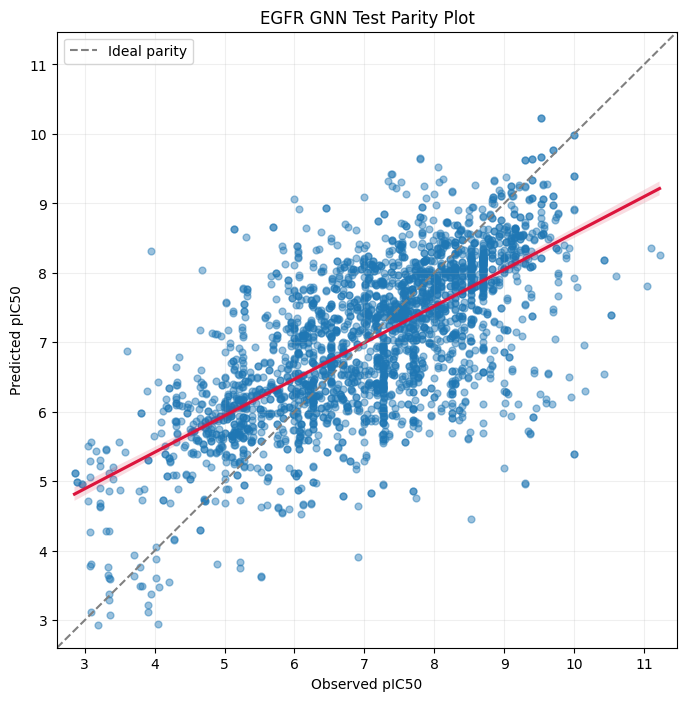

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns  # <--- ADD THIS LINE TO FIX THE ERROR

# Final evaluation on the held-out test set
from sklearn.metrics import mean_squared_error, r2_score

if len(graphs) > 0 and test_loader is not None and len(test_graphs) > 0:
    if best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        print(f'✓ Loaded best checkpoint from {best_model_path}')
    
    model.eval()
    test_preds = []
    test_targets = []
    
    with torch.no_grad():
        for batch in test_loader:
            x_test = batch.x.float().to(device)
            edge_index_test = batch.edge_index.to(device) if batch.edge_index is not None else torch.zeros((2, 0), dtype=torch.long, device=device)
            if hasattr(batch, 'edge_attr') and batch.edge_attr is not None:
                edge_attr_test = batch.edge_attr.float().to(device)
            else:
                n_edges_test = edge_index_test.shape[1]
                edge_attr_test = torch.randn((n_edges_test, edge_feat_dim), dtype=torch.float, device=device) * 0.01 + 0.1
            pos_test = batch.pos.float().to(device) if (hasattr(batch, 'pos') and batch.pos is not None) else None
            batch_tensor_test = batch.batch.to(device)
            global_features_test = batch.global_features.float().to(device) if (hasattr(batch, 'global_features') and batch.global_features is not None) else None
            fingerprint_test = batch.fingerprint.float().to(device) if (hasattr(batch, 'fingerprint') and batch.fingerprint is not None) else None
            pocket_test = batch.pocket_embedding.float().to(device) if (hasattr(batch, 'pocket_embedding') and batch.pocket_embedding is not None) else None
            
            preds_test = model(
                x_test,
                edge_index_test,
                batch_tensor_test,
                edge_attr=edge_attr_test,
                global_features=global_features_test,
                pos=pos_test,
                fingerprint=fingerprint_test,
                pocket_embedding=pocket_test,
            ).view(-1)
            
            if y_std > 0:
                preds_test = preds_test * y_std + y_mean
            targets_test = batch.y.view(-1).float().to(device)
            
            test_preds.append(preds_test.cpu().numpy())
            test_targets.append(targets_test.cpu().numpy())
    
    y_test_true = np.concatenate(test_targets)
    y_test_pred = np.concatenate(test_preds)
    
    test_r2 = r2_score(y_test_true, y_test_pred) if len(np.unique(y_test_true)) > 1 else float('nan')
    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
    parity_slope, parity_intercept = np.polyfit(y_test_true, y_test_pred, 1)
    
    print(f'\nTest R²:  {test_r2:.4f}')
    print(f'Test RMSE: {test_rmse:.4f}')
    print(f'Parity fit: y_pred = {parity_slope:.4f} * y_true + {parity_intercept:.4f}')
    
    plt.figure(figsize=(8, 8))
    sns.regplot(x=y_test_true, y=y_test_pred, scatter_kws={'alpha': 0.45, 's': 24}, line_kws={'color': 'crimson'})
    lims = [min(y_test_true.min(), y_test_pred.min()) - 0.25, max(y_test_true.max(), y_test_pred.max()) + 0.25]
    plt.plot(lims, lims, '--', color='gray', linewidth=1.5, label='Ideal parity')
    plt.xlim(lims)
    plt.ylim(lims)
    plt.xlabel('Observed pIC50')
    plt.ylabel('Predicted pIC50')
    plt.title('EGFR GNN Test Parity Plot')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()
else:
    print('No test set available for evaluation')

In [7]:
# ===== UTILITY: Convert Predicted Graphs Back to SMILES =====

def graph_to_smiles(graph_data):
    """
    Converts a PyG graph back to a SMILES string.
    Handles both the legacy atomic-number layout and the newer
    one-hot atom-type layout, and ignores the edge-distance feature.
    """
    from rdkit import Chem

    atom_symbols = ['C', 'N', 'O', 'F', 'S', 'Cl']
    bond_types = [
        Chem.rdchem.BondType.SINGLE,
        Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE,
        Chem.rdchem.BondType.AROMATIC,
    ]

    try:
        mol = Chem.RWMol()

        x = graph_data.x.detach().cpu().numpy() if hasattr(graph_data.x, 'detach') else graph_data.x
        if x is None or len(x) == 0:
            return None

        node_dim = x.shape[1] if getattr(x, 'ndim', 0) == 2 else 0
        atom_type_dim = max(node_dim - 2, 0)
        has_one_hot_atom_types = atom_type_dim > 0 and len(atom_symbols) >= atom_type_dim

        for node_features in x:
            atom = None

            if has_one_hot_atom_types:
                atom_type_slice = np.asarray(node_features[:atom_type_dim], dtype=float)
                if atom_type_slice.size and np.all(np.isfinite(atom_type_slice)):
                    one_hot_like = np.all((atom_type_slice >= -1e-6) & (atom_type_slice <= 1.0 + 1e-6)) and np.isclose(atom_type_slice.sum(), 1.0, atol=1e-3)
                    if one_hot_like:
                        atom_idx = int(np.argmax(atom_type_slice))
                        if atom_idx < len(atom_symbols):
                            atom = Chem.Atom(atom_symbols[atom_idx])

            if atom is None:
                raw_atomic_num = int(round(float(node_features[0])))
                if raw_atomic_num > 0:
                    atom = Chem.Atom(raw_atomic_num)

            if atom is None:
                return None

            mol.AddAtom(atom)

        edge_index = graph_data.edge_index.detach().cpu().numpy() if hasattr(graph_data.edge_index, 'detach') else graph_data.edge_index
        edge_attr = graph_data.edge_attr.detach().cpu().numpy() if hasattr(graph_data.edge_attr, 'detach') else graph_data.edge_attr
        if edge_index is not None and edge_index.size > 0:
            added_bonds = set()
            num_edges = edge_index.shape[1] if edge_index.shape[0] == 2 else edge_index.shape[0]

            for edge_idx in range(num_edges):
                if edge_index.shape[0] == 2:
                    start = int(edge_index[0, edge_idx])
                    end = int(edge_index[1, edge_idx])
                else:
                    start = int(edge_index[edge_idx, 0])
                    end = int(edge_index[edge_idx, 1])

                bond_pair = tuple(sorted((start, end)))
                if start == end or bond_pair in added_bonds:
                    continue

                bond_type = Chem.rdchem.BondType.SINGLE
                if edge_attr is not None and edge_idx < len(edge_attr):
                    bond_slice = np.asarray(edge_attr[edge_idx], dtype=float)
                    if bond_slice.size >= 4:
                        bond_type_idx = int(np.argmax(bond_slice[:4]))
                        bond_type = bond_types[bond_type_idx]

                try:
                    mol.AddBond(bond_pair[0], bond_pair[1], bond_type)
                    added_bonds.add(bond_pair)
                except Exception as bond_error:
                    print(f'Bond reconstruction error for {bond_pair}: {bond_error}')

        mol = mol.GetMol()
        try:
            Chem.SanitizeMol(mol)
        except Exception as sanitize_error:
            print(f'SanitizeMol failed: {sanitize_error}')
            try:
                return Chem.MolToSmiles(mol, canonical=False)
            except Exception as fallback_error:
                print(f'Fallback MolToSmiles failed: {fallback_error}')
                return None

        try:
            return Chem.MolToSmiles(mol, canonical=True)
        except Exception as smiles_error:
            print(f'MolToSmiles failed: {smiles_error}')
            return None

    except Exception as e:
        print(f'graph_to_smiles failed: {e}')
        return None

print('✓ Graph-to-SMILES conversion function ready')


✓ Graph-to-SMILES conversion function ready


In [8]:
# Diagnostic: reconstruct a single real test graph
if len(test_graphs) > 0:
    sample_graph = test_graphs[0]
    print('Testing test_graphs[0]')
    print(f'  x shape: {tuple(sample_graph.x.shape) if hasattr(sample_graph, "x") and sample_graph.x is not None else None}')
    print(f'  edge_index shape: {tuple(sample_graph.edge_index.shape) if hasattr(sample_graph, "edge_index") and sample_graph.edge_index is not None else None}')
    print(f'  edge_attr shape: {tuple(sample_graph.edge_attr.shape) if hasattr(sample_graph, "edge_attr") and sample_graph.edge_attr is not None else None}')
    try:
        smiles = graph_to_smiles(sample_graph)
        print(f'Reconstructed SMILES: {smiles}')
    except Exception as error:
        print(f'ERROR during reconstruction: {type(error).__name__}: {error}')
else:
    print('ERROR: test_graphs is empty')

Testing test_graphs[0]
  x shape: (40, 8)
  edge_index shape: (2, 88)
  edge_attr shape: (88, 5)
Reconstructed SMILES: CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1


✓ Saved training diagnostics: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\training_diagnostics.png


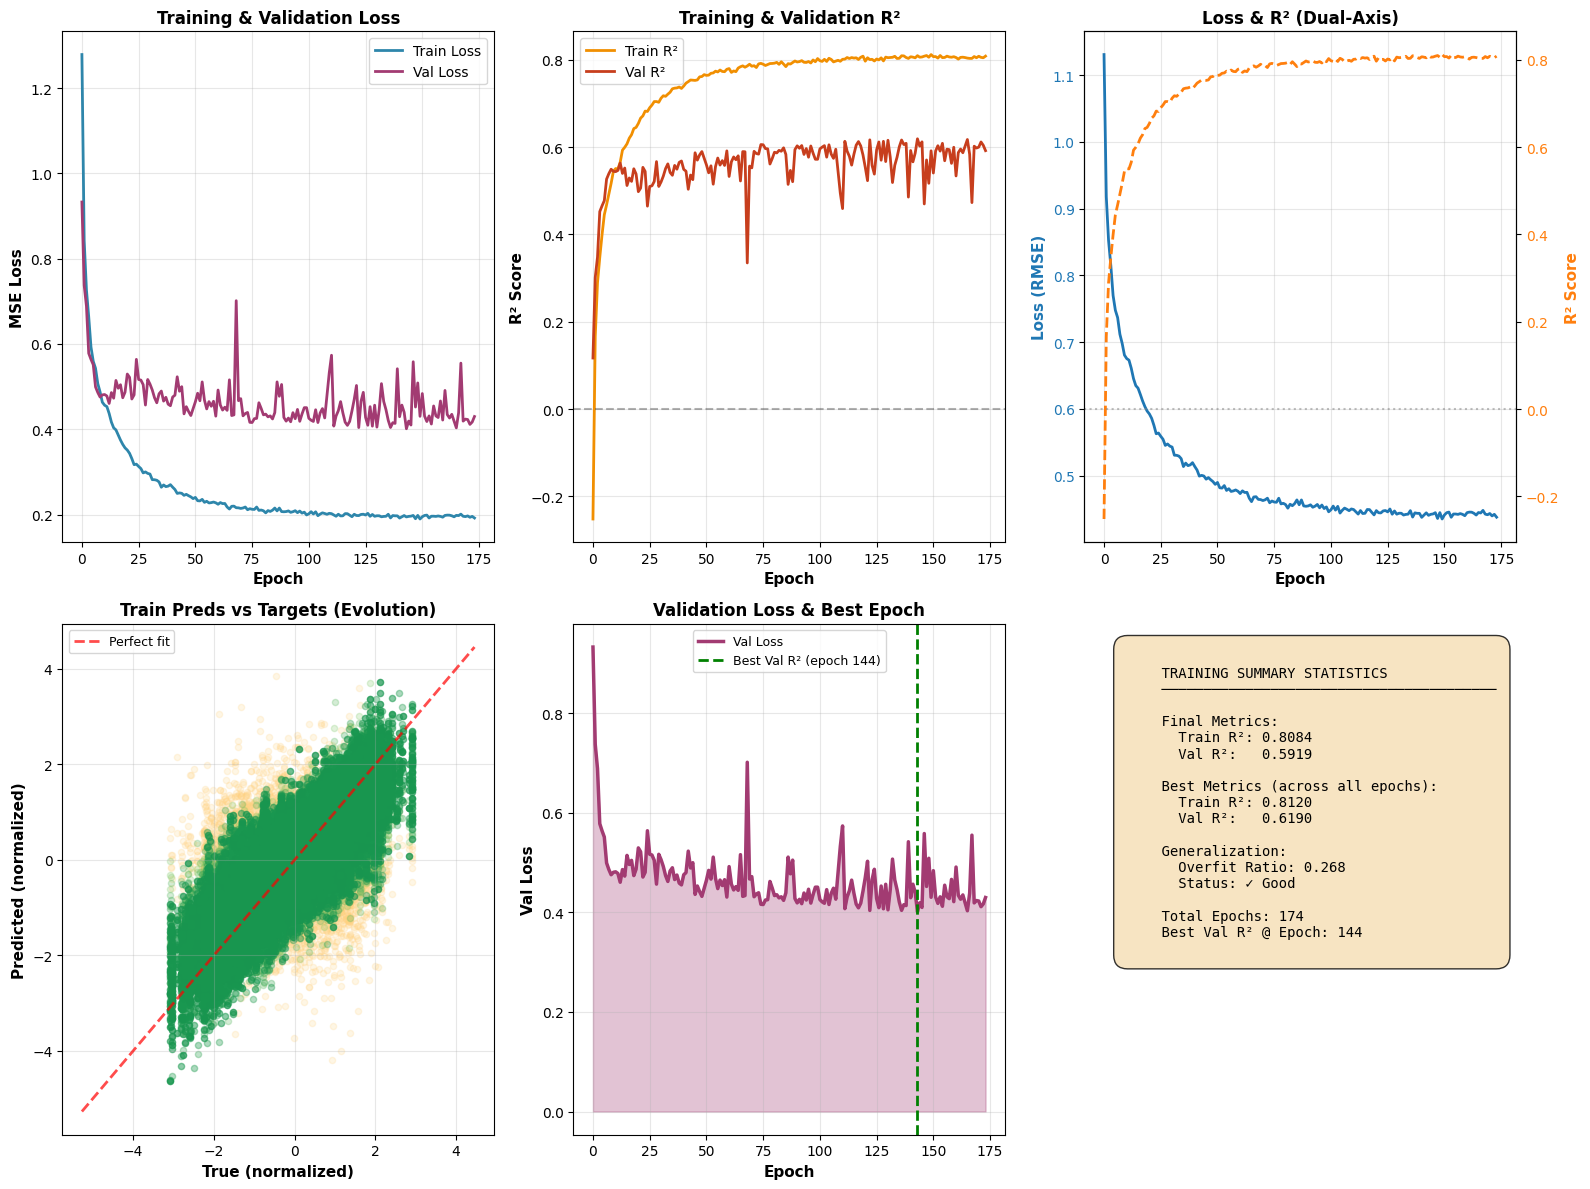


📊 Training Summary:
  Final Train R²: 0.8084
  Final Val R²:   0.5919
  Best Val R² achieved at epoch 144: 0.6190


In [9]:
# ===== TRAINING VISUALIZATION: Loss, R², and Prediction Curves =====

if len(train_losses) > 0:
    import seaborn as sns
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Loss curve (train vs val)
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(train_losses, label='Train Loss', linewidth=2, color='#2E86AB')
    ax1.plot(val_losses, label='Val Loss', linewidth=2, color='#A23B72')
    ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax1.set_ylabel('MSE Loss', fontsize=11, fontweight='bold')
    ax1.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. R² curve (train vs val)
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(train_r2_list, label='Train R²', linewidth=2, color='#F18F01')
    ax2.plot(val_r2_list, label='Val R²', linewidth=2, color='#C73E1D')
    ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
    ax2.set_title('Training & Validation R²', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # 3. Loss + R² dual-axis (from Medium article pattern)
    ax3 = plt.subplot(2, 3, 3)
    color_loss = 'tab:blue'
    ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Loss (RMSE)', color=color_loss, fontsize=11, fontweight='bold')
    rmse_train = np.sqrt(np.array(train_losses))
    ax3.plot(rmse_train, color=color_loss, linewidth=2, label='Train RMSE')
    ax3.tick_params(axis='y', labelcolor=color_loss)
    ax3.grid(True, alpha=0.3)
    
    ax3_twin = ax3.twinx()
    color_r2 = 'tab:orange'
    ax3_twin.set_ylabel('R² Score', color=color_r2, fontsize=11, fontweight='bold')
    ax3_twin.plot(train_r2_list, color=color_r2, linewidth=2, label='Train R²', linestyle='--')
    ax3_twin.tick_params(axis='y', labelcolor=color_r2)
    ax3_twin.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    
    ax3.set_title('Loss & R² (Dual-Axis)', fontsize=12, fontweight='bold')
    
    # 4. Train predictions vs targets (first 100 epochs if available)
    ax4 = plt.subplot(2, 3, 4)
    n_plots = min(20, len(train_preds_history))
    for i in range(n_plots):
        epoch_idx = int(len(train_preds_history) * (i / n_plots))
        pred = train_preds_history[epoch_idx]
        targ = train_targets_history[epoch_idx]
        r2_epoch = train_r2_list[epoch_idx]
        alpha = 0.2 + 0.6 * (i / n_plots)  # Gradually increase alpha
        color_value = plt.cm.RdYlGn((r2_epoch + 1) / 2)
        ax4.scatter(targ, pred, alpha=alpha, s=20, color=color_value)
    
    # Add perfect prediction line
    mn = min(min([t.min() for t in train_targets_history]), min([p.min() for p in train_preds_history]))
    mx = max(max([t.max() for t in train_targets_history]), max([p.max() for p in train_preds_history]))
    ax4.plot([mn, mx], [mn, mx], 'r--', linewidth=2, alpha=0.7, label='Perfect fit')
    ax4.set_xlabel('True (normalized)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Predicted (normalized)', fontsize=11, fontweight='bold')
    ax4.set_title('Train Preds vs Targets (Evolution)', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # 5. Early stops and Best epoch identification
    ax5 = plt.subplot(2, 3, 5)
    best_val_r2_idx = np.argmax(val_r2_list)
    ax5.fill_between(range(len(val_losses)), val_losses, alpha=0.3, color='#A23B72')
    ax5.plot(val_losses, linewidth=2.5, color='#A23B72', label='Val Loss')
    ax5.axvline(x=best_val_r2_idx, color='green', linestyle='--', linewidth=2, label=f'Best Val R² (epoch {best_val_r2_idx+1})')
    ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Val Loss', fontsize=11, fontweight='bold')
    ax5.set_title('Validation Loss & Best Epoch', fontsize=12, fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    # 6. Summary metrics box
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    final_train_r2 = train_r2_list[-1]
    final_val_r2 = val_r2_list[-1]
    best_train_r2 = max(train_r2_list)
    best_val_r2 = max(val_r2_list)
    overfit_ratio = (final_train_r2 - final_val_r2) / max(abs(final_train_r2), 0.01)
    
    summary_text = f"""
    TRAINING SUMMARY STATISTICS
    {'─' * 40}
    
    Final Metrics:
      Train R²: {final_train_r2:.4f}
      Val R²:   {final_val_r2:.4f}
      
    Best Metrics (across all epochs):
      Train R²: {best_train_r2:.4f}
      Val R²:   {best_val_r2:.4f}
      
    Generalization:
      Overfit Ratio: {overfit_ratio:.3f}
      Status: {'✓ Good' if abs(overfit_ratio) < 0.3 else '⚠ Possible Overfit' if abs(overfit_ratio) < 0.5 else '✗ Severe Overfit'}
      
    Total Epochs: {len(train_losses)}
    Best Val R² @ Epoch: {best_val_r2_idx + 1}
    """
    
    ax6.text(0.1, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, pad=1))
    
    plt.tight_layout()
    training_viz_out = OUT / 'training_diagnostics.png'
    plt.savefig(training_viz_out, dpi=300, bbox_inches='tight')
    print(f'✓ Saved training diagnostics: {training_viz_out}')
    plt.show()
    
    print(f'\n📊 Training Summary:')
    print(f'  Final Train R²: {final_train_r2:.4f}')
    print(f'  Final Val R²:   {final_val_r2:.4f}')
    print(f'  Best Val R² achieved at epoch {best_val_r2_idx + 1}: {best_val_r2:.4f}')
else:
    print('⚠ No training history available for visualization')


In [10]:
# ===== TEST VALIDATION: Reconstruct SMILES & Check Chemical Validity =====

if len(test_graphs) > 0:
    print('\n' + '=' * 70)
    print('SMILES RECONSTRUCTION & CHEMICAL VALIDITY CHECK')
    print('=' * 70)
    
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen
    
    valid_smiles_list = []
    invalid_count = 0
    
    print(f'\nAttempting to reconstruct SMILES from {len(test_graphs)} test graphs...\n')
    
    for i, graph in enumerate(test_graphs):
        smiles_reconstructed = graph_to_smiles(graph)
        if smiles_reconstructed is None:
            invalid_count += 1
            continue
        mol_check = Chem.MolFromSmiles(smiles_reconstructed)
        if mol_check is None:
            invalid_count += 1
            continue
        mw = Descriptors.MolWt(mol_check)
        logp = Crippen.MolLogP(mol_check)
        valid_smiles_list.append(smiles_reconstructed)
    
    # Summary
    if len(test_graphs) > 0:
        total_checked = len(test_graphs)
        valid_count = total_checked - invalid_count
        validity_rate = 100 * valid_count / total_checked
        
        print(f'\n{"─" * 70}')
        print(f'Reconstruction Results (all test graphs):')
        print(f'  Valid:   {valid_count} ({validity_rate:.1f}%)')
        print(f'  Invalid: {invalid_count} ({100 - validity_rate:.1f}%)')
        print(f'{"─" * 70}')
else:
    print('⚠ No test graphs available for SMILES reconstruction')



SMILES RECONSTRUCTION & CHEMICAL VALIDITY CHECK

Attempting to reconstruct SMILES from 2942 test graphs...



[15:30:52] Explicit valence for atom # 7 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 7 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 7 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 7 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 6 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 6 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 6 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 18 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 29 N, 4, is greater than permitted
[15:30:52] Explicit valence for atom # 6 N, 4, is greater than permitted


SanitizeMol failed: Explicit valence for atom # 7 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 7 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 6 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 6 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 29 N, 4, is greater than permitted


[15:30:53] Explicit valence for atom # 20 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 20 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 20 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 20 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 16 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 16 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 14 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 20 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 14 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 20 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 19 N, 4, is greater than permitted
[15:30:53] Explicit valence for atom # 16 N, 4, is greater than permitted


SanitizeMol failed: Explicit valence for atom # 20 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 20 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 16 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 14 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 14 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 19 N, 4, is greater than permitted


...

SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 28 29 30 31 32 33 34 35 36
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 27 28 29 30 31 32 33 34 35
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25 26 27
SanitizeMol failed: Explicit valence for atom # 9 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 9 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 9 N, 4, is greater than permitted
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 21 22 23 24 25 26 27 28 29
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25 26 27
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 19 20 21 22 23 24 25 26 27
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 22 23 24 25 26 27 28 29 30
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms: 25 26 27 28 29 30 31 32 33
SanitizeMol failed: Can't kekulize mol.  Unkekulized atoms

[15:30:55] Explicit valence for atom # 17 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 17 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 14 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 14 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 20 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 20 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4

SanitizeMol failed: Explicit valence for atom # 17 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 14 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 20 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 22 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 20 N, 4, is greater than permitted
SanitizeMol

[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:30:55] Explicit valence for atom # 1 N, 4, is g

SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 1 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 19 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 20 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 21 N, 4, is greater than permitted
SanitizeMol failed: Explicit valence for atom # 22 N, 4, is greater than permitted
SanitizeMol 

In [11]:
if 'train_r2_list' in globals() and 'val_r2_list' in globals() and len(train_r2_list) > 0:
    best_train_r2 = float(np.nanmax(train_r2_list))
    best_val_r2 = float(np.nanmax(val_r2_list))
    print(f'Best recorded Train R²: {best_train_r2:.4f}')
    print(f'Best recorded Val R²:   {best_val_r2:.4f}')
else:
    print('Training history is not available in the current kernel state.')

Best recorded Train R²: 0.8120
Best recorded Val R²:   0.6190
